<a href="https://colab.research.google.com/github/HimanshuRa0/Deep-learning/blob/main/EXP_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 8: Image Classifier with Keras and CNN for Fashion MNIST

**Objective:** Build an image classifier using Keras and Convolutional Neural Networks (CNN) for the Fashion MNIST dataset.

**Language:** Python  
**Estimated Time:** 2 hours  
**Libraries Used:** NumPy, Matplotlib, TensorFlow / Keras, scikit-learn


## 1. Introduction

Fashion MNIST is a dataset of 28x28 grayscale images of clothing items. It contains 10 classes such as T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, and Ankle boot.

In this experiment, we use a Convolutional Neural Network (CNN) to learn image patterns and classify clothing categories accurately.


## 2. Aim of the Experiment

In this notebook, we will:

1. Load the Fashion MNIST dataset
2. Preprocess the images
3. Build a CNN model using Keras
4. Train the model
5. Evaluate classification accuracy
6. Visualize predictions and confusion matrix


In [1]:
# Install if needed
# !pip install tensorflow matplotlib numpy scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

## 3. Load the Fashion MNIST Dataset


In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print('Training images shape:', x_train.shape)
print('Training labels shape:', y_train.shape)
print('Testing images shape:', x_test.shape)
print('Testing labels shape:', y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


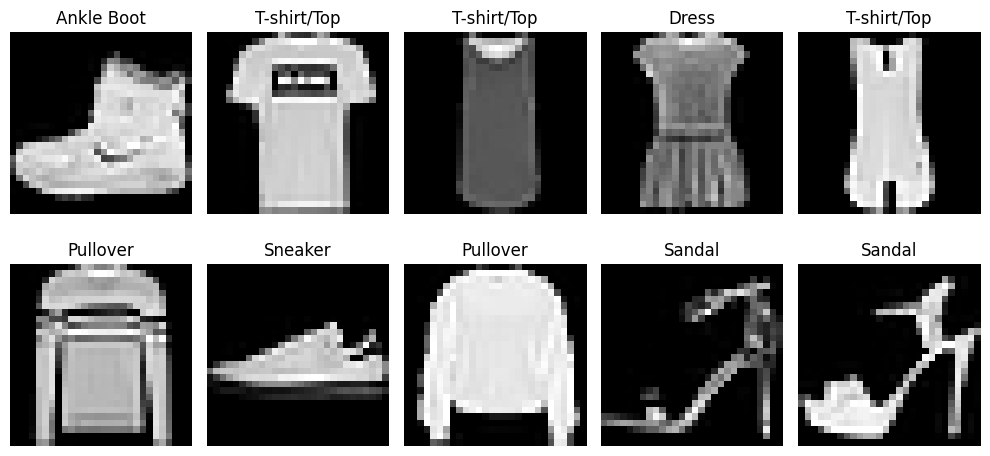

In [4]:
class_names = [
    'T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot'
]

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

We normalize pixel values to the range [0, 1], reshape images to include the channel dimension, and convert labels to one-hot vectors.


In [5]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print('Preprocessed training images:', x_train.shape)
print('Preprocessed testing images:', x_test.shape)
print('One-hot training labels:', y_train_cat.shape)

Preprocessed training images: (60000, 28, 28, 1)
Preprocessed testing images: (10000, 28, 28, 1)
One-hot training labels: (60000, 10)


## 5. Build the CNN Model


In [6]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model


In [7]:
history = model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 0.7776 - loss: 0.6158 - val_accuracy: 0.8495 - val_loss: 0.4096
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.8576 - loss: 0.3961 - val_accuracy: 0.8763 - val_loss: 0.3355
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.8750 - loss: 0.3417 - val_accuracy: 0.8893 - val_loss: 0.3072
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.8866 - loss: 0.3111 - val_accuracy: 0.8938 - val_loss: 0.2927
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.8949 - loss: 0.2872 - val_accuracy: 0.9007 - val_loss: 0.2782
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - accuracy: 0.9010 - loss: 0.2677 - val_accuracy: 0.9043 - val_loss: 0.2679
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.9074 - loss: 0.2510 - val_accuracy: 0.9090 - val_loss: 0.2592
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.9130 - loss: 0.2362 - 

## 7. Plot Accuracy and Loss


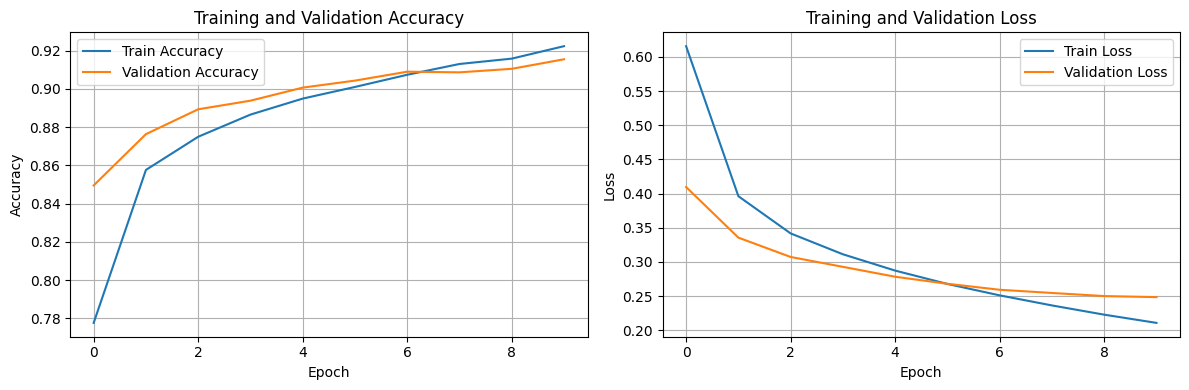

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 8. Evaluate the Model


In [9]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print('Test Loss:', round(test_loss, 4))
print('Test Accuracy:', round(test_accuracy, 4))

Test Loss: 0.2689
Test Accuracy: 0.9066


## 9. Predictions on Test Data


In [10]:
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print('Sample predicted labels:', y_pred[:10])

Sample predicted labels: [9 2 1 1 6 1 4 6 5 7]


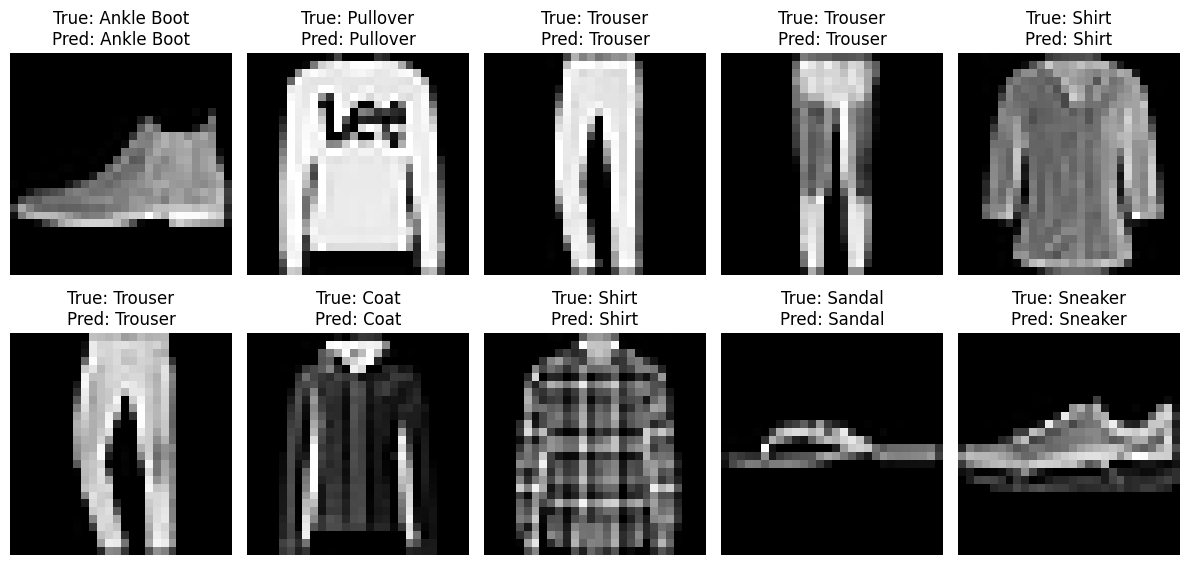

In [11]:
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f'True: {class_names[y_test[i]]}\nPred: {class_names[y_pred[i]]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 10. Confusion Matrix and Classification Report


In [12]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n')
print(cm)

Confusion Matrix:

[[879   0  20  23   3   1  69   0   5   0]
 [  1 972   1  19   3   0   3   0   1   0]
 [ 16   1 887  12  46   0  37   0   1   0]
 [ 17   2  10 918  28   0  25   0   0   0]
 [  1   1  59  28 867   0  43   0   1   0]
 [  1   0   0   0   0 992   0   5   0   2]
 [129   0  86  28  83   0 668   0   6   0]
 [  0   0   0   0   0  26   0 952   0  22]
 [  3   1   5   3   3   3   2   1 979   0]
 [  0   0   0   0   0   8   0  39   1 952]]


In [13]:
print('Classification Report:\n')
print(classification_report(y_test, y_pred, target_names=class_names))

Classification Report:

              precision    recall  f1-score   support

 T-shirt/Top       0.84      0.88      0.86      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.83      0.89      0.86      1000
       Dress       0.89      0.92      0.90      1000
        Coat       0.84      0.87      0.85      1000
      Sandal       0.96      0.99      0.98      1000
       Shirt       0.79      0.67      0.72      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle Boot       0.98      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



## 11. Conclusion

In this experiment, we built and trained a CNN-based image classifier on the Fashion MNIST dataset using Keras. The model learned useful visual patterns from clothing images and predicted their classes with good accuracy. This demonstrates how CNNs are effective for image classification tasks.
